Inputs

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

In [23]:
import pandas as pd

# Use the actual overlapping sample between SP500 and 3M T-bill
start = "1990-01-02"   # First date available in tbill
end = None             # Up to most recent data

# === S&P 500 local file ===
sp500_raw = pd.read_csv(
    "../../data/macro_processed/sp500_processed.csv",
    parse_dates=["date"]
).set_index("date")

# Keep only the 'value' column and rename it to 'SP500'
sp500 = sp500_raw[["value"]].rename(columns={"value": "SP500"})

# Restrict SP500 to sample starting in 1990
sp500 = sp500.loc[start:end]

# === 3M T-bill local file ===
tbill_raw = pd.read_csv(
    "../../data/macro_processed/3m_yield_processed.csv",
    parse_dates=["date"]
).set_index("date")

# Keep only 'value' column and rename it to 'TB3MS'
tbill = tbill_raw[["value"]].rename(columns={"value": "TB3MS"})

# Restrict T-bill to sample starting in 1990
tbill = tbill.loc[start:end]

print("S&P span:", sp500.index.min(), "to", sp500.index.max())
print("T-bill span:", tbill.index.min(), "to", tbill.index.max())

S&P span: 1990-01-31 00:00:00 to 2025-11-14 00:00:00
T-bill span: 1990-01-02 00:00:00 to 2025-11-14 00:00:00


In [ ]:
# # Download data
# start = "1980-01-01"
# end = None  # up to today

# # S&P 500 from Yahoo
# sp500_raw = yf.download("^GSPC", start=start, end=end,
#                         auto_adjust=True, progress=False)

# # Take adjusted close (already adjusted via auto_adjust=True)
# sp500 = sp500_raw[["Close"]].rename(columns={"Close": "SP500"})

# # 3M T-bill from FRED (annualized %)
# tbill = pdr.DataReader("TB3MS", "fred", start, end)

# print("S&P span:", sp500.index.min(), "to", sp500.index.max())
# print("T-bill span:", tbill.index.min(), "to", tbill.index.max())

S&P span: 1980-01-02 00:00:00 to 2025-11-26 00:00:00
T-bill span: 1980-01-01 00:00:00 to 2025-10-01 00:00:00


In [33]:
import pandas as pd
import numpy as np

# --- Build monthly S&P500 returns ---
sp500_m = sp500.resample("M").last()

# extract the level as a 1-D Series
sp500_level = sp500_m["SP500"]

sp500_ret = sp500_level.pct_change().dropna()
sp500_ret.index = sp500_ret.index.to_period("M")


# --- Build monthly T-bill returns from annualized rate ---
tbill_m = tbill.resample("M").last()

rf_ann = tbill_m["TB3MS"] / 100.0  # convert % → decimal

# annual → monthly simple return
rf_monthly = (1 + rf_ann) ** (1/12) - 1
rf_monthly = rf_monthly.dropna()
rf_monthly.index = rf_monthly.index.to_period("M")


# --- Align both series to same monthly index ---
idx = sp500_ret.index.intersection(rf_monthly.index)

sp500_ret = sp500_ret.loc[idx]
rf_monthly = rf_monthly.loc[idx]


# --- Build data frame ---
data = pd.DataFrame({
    "sp500_ret": sp500_ret,
    "rf_ret": rf_monthly
})
data["erp"] = data["sp500_ret"] - data["rf_ret"]

print("\nFirst rows of monthly ERP data:")
print(data.head())


First rows of monthly ERP data:
         sp500_ret    rf_ret       erp
date                                  
1990-02   0.008539  0.006465  0.002074
1990-03   0.024255  0.006488  0.017767
1990-04  -0.026887  0.006488 -0.033375
1990-05   0.091989  0.006442  0.085547
1990-06  -0.008886  0.006434 -0.015320


/var/folders/h_/5wg7lw3n2djc8yh6g107mytm0000gn/T/ipykernel_96981/1211281510.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500_m = sp500.resample("M").last()
/var/folders/h_/5wg7lw3n2djc8yh6g107mytm0000gn/T/ipykernel_96981/1211281510.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tbill_m = tbill.resample("M").last()


In [34]:
# ---- Geometric average monthly return ----
def geo_ret(r: pd.Series) -> float:
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    gross = (1 + r).prod()
    return gross ** (1 / len(r)) - 1

erp = data["erp"]

g_erp_m = geo_ret(erp)
a_erp_m = erp.mean()
std_erp = erp.std()

print("\nERP geometric monthly mean   : {:.4%}".format(g_erp_m))
print("ERP arithmetic monthly mean  : {:.4%}".format(a_erp_m))
print("ERP monthly std deviation    : {:.4%}".format(std_erp))
print("ERP 5th / 95th percentiles   : {:.4%} / {:.4%}".format(
    erp.quantile(0.05), erp.quantile(0.95)
))


ERP geometric monthly mean   : 0.4781%
ERP arithmetic monthly mean  : 0.5690%
ERP monthly std deviation    : 4.2410%
ERP 5th / 95th percentiles   : -7.1578% / 6.9625%


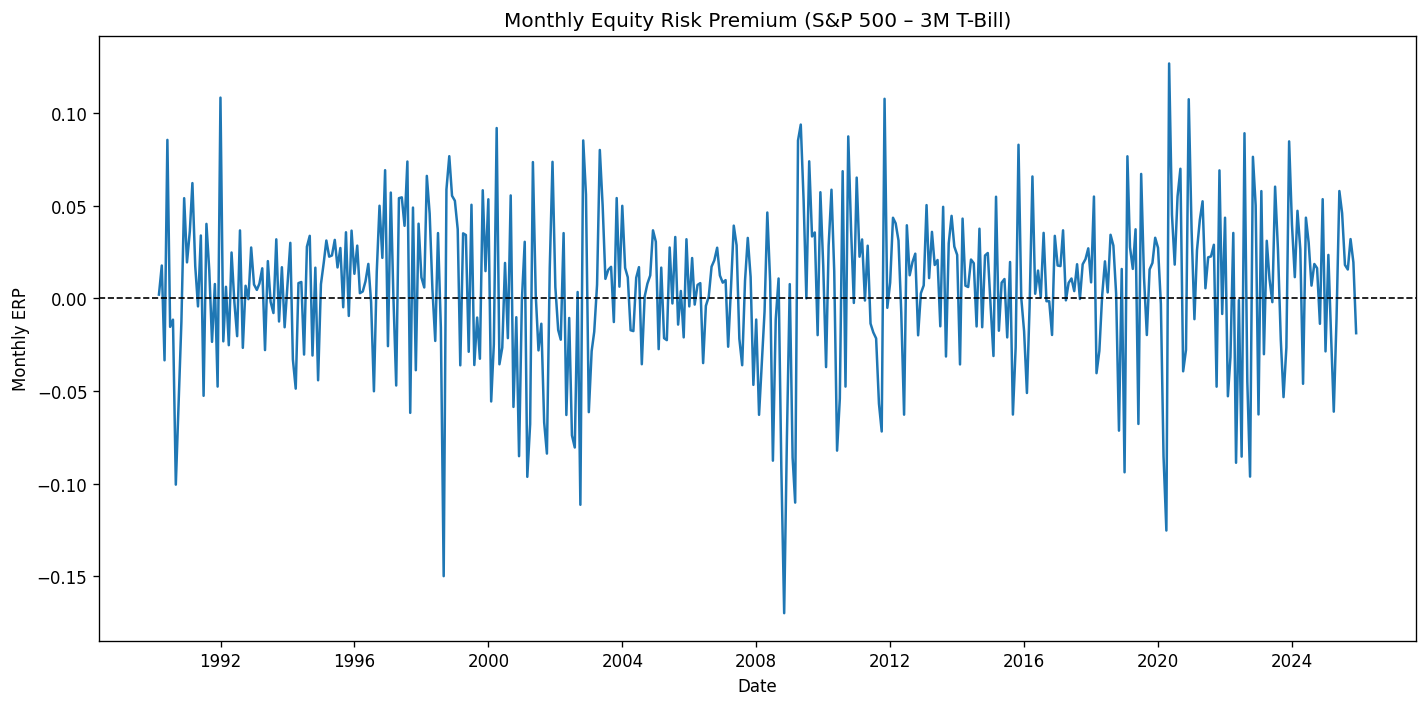

In [35]:
import matplotlib.pyplot as plt

# Convert PeriodIndex → Timestamp for plotting
data_plot = data.copy()
data_plot.index = data_plot.index.to_timestamp("M")

plt.figure(figsize=(12, 6))
plt.plot(data_plot.index, data_plot["erp"], label="ERP")
plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.title("Monthly Equity Risk Premium (S&P 500 – 3M T-Bill)")
plt.ylabel("Monthly ERP")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

Strategy 1 using stocks and cash




===== Monthly Equity Risk Premium – Summary =====
Arithmetic mean (monthly)   : 0.5690%
Geometric mean (monthly)    : 0.4781%
Std dev (monthly)           : 4.2410%
5th percentile              : -7.1578%
50th percentile (median)    : 0.9414%
95th percentile             : 6.9625%


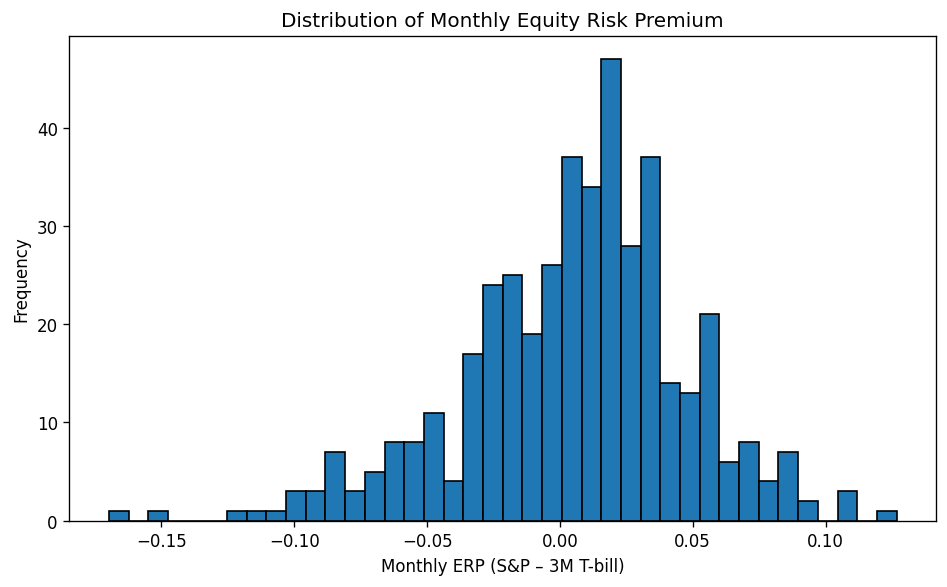

In [36]:
# Distribution of Monthly Equity Risk Premium

erp = data["erp"].dropna()

print("\n===== Monthly Equity Risk Premium – Summary =====")
print("Arithmetic mean (monthly)   : {:.4%}".format(erp.mean()))
print("Geometric mean (monthly)    : {:.4%}".format(
    (1 + erp).prod() ** (1 / len(erp)) - 1
))
print("Std dev (monthly)           : {:.4%}".format(erp.std()))
print("5th percentile              : {:.4%}".format(erp.quantile(0.05)))
print("50th percentile (median)    : {:.4%}".format(erp.quantile(0.50)))
print("95th percentile             : {:.4%}".format(erp.quantile(0.95)))

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(erp, bins=40, edgecolor="black")
plt.title("Distribution of Monthly Equity Risk Premium")
plt.xlabel("Monthly ERP (S&P – 3M T-bill)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [39]:
# Z-scores of monthly ERP
erp = data["erp"].dropna()
erp_mean = erp.mean()
erp_std = erp.std()
z = (erp - erp_mean) / erp_std

print("\nERP mean (monthly): {:.4%}".format(erp_mean))
print("ERP std  (monthly): {:.4%}".format(erp_std))



ERP mean (monthly): 0.5690%
ERP std  (monthly): 4.2410%


In [41]:
# Stock-weight rule
def stock_weight_from_z(z_val: float) -> float:
    if z_val >= 2:
        return 1.00
    elif z_val >= 1:
        return 0.75
    elif z_val > -1:
        return 0.50
    elif z_val > -2:
        return 0.25
    else:
        return 0.00

w_stock = z.apply(stock_weight_from_z)
w_cash = 1 - w_stock

# Use last month's z-score to set this month's weights (no look-ahead)
w_stock = w_stock.shift(1).fillna(0.5)
w_cash = w_cash.shift(1).fillna(0.5)

# Line up weights with returns
strategy = pd.DataFrame({
    "w_stock": w_stock,
    "w_cash": w_cash
}).join(data[["sp500_ret", "rf_ret"]], how="inner")

In [42]:
# Cash return = 0%
cash_ret = 0.0

# Dynamic ERP timing strategy
strategy["ret_dyn"] = (
    strategy["w_stock"] * strategy["sp500_ret"] +
    strategy["w_cash"] * cash_ret
)

# Benchmark: constant mix equal to the average risky load of the dynamic strategy
w_bar = strategy["w_stock"].mean()

strategy["ret_bench"] = (
    w_bar * strategy["sp500_ret"] +
    (1 - w_bar) * cash_ret
)

In [43]:
# ---- Annualized geometric returns ----
def geo_ret(r: pd.Series) -> float:
    r = r.dropna()
    gross = (1 + r).prod()
    return gross ** (1 / len(r)) - 1

g_dyn_m = geo_ret(strategy["ret_dyn"])
g_bench_m = geo_ret(strategy["ret_bench"])

g_dyn_a = (1 + g_dyn_m) ** 12 - 1
g_bench_a = (1 + g_bench_m) ** 12 - 1

print("\n===== Geometric Annualized Returns – STOCK–CASH =====")
print("Dynamic ERP strategy           : {:.4%}".format(g_dyn_a))
print("Benchmark (avg risky/safe mix) : {:.4%}".format(g_bench_a))


# ---- Sharpe Ratios (annualized, with T-bill as risk-free) ----
def sharpe_annual(excess_ret: pd.Series) -> float:
    excess_ret = excess_ret.dropna()
    if excess_ret.std() == 0:
        return np.nan
    return (excess_ret.mean() / excess_ret.std()) * np.sqrt(12)

ex_dyn = strategy["ret_dyn"] - strategy["rf_ret"]
ex_bench = strategy["ret_bench"] - strategy["rf_ret"]

sharpe_dyn = sharpe_annual(ex_dyn)
sharpe_bench = sharpe_annual(ex_bench)

print("\n===== Annualized Sharpe Ratios – STOCK–CASH (vs 3M T-Bill) =====")
print("Dynamic ERP strategy           : {:.3f}".format(sharpe_dyn))
print("Benchmark (avg risky/safe mix) : {:.3f}".format(sharpe_bench))



===== Geometric Annualized Returns – STOCK–CASH =====
Dynamic ERP strategy           : 4.8182%
Benchmark (avg risky/safe mix) : 4.5487%

===== Annualized Sharpe Ratios – STOCK–CASH (vs 3M T-Bill) =====
Dynamic ERP strategy           : 0.320
Benchmark (avg risky/safe mix) : 0.276


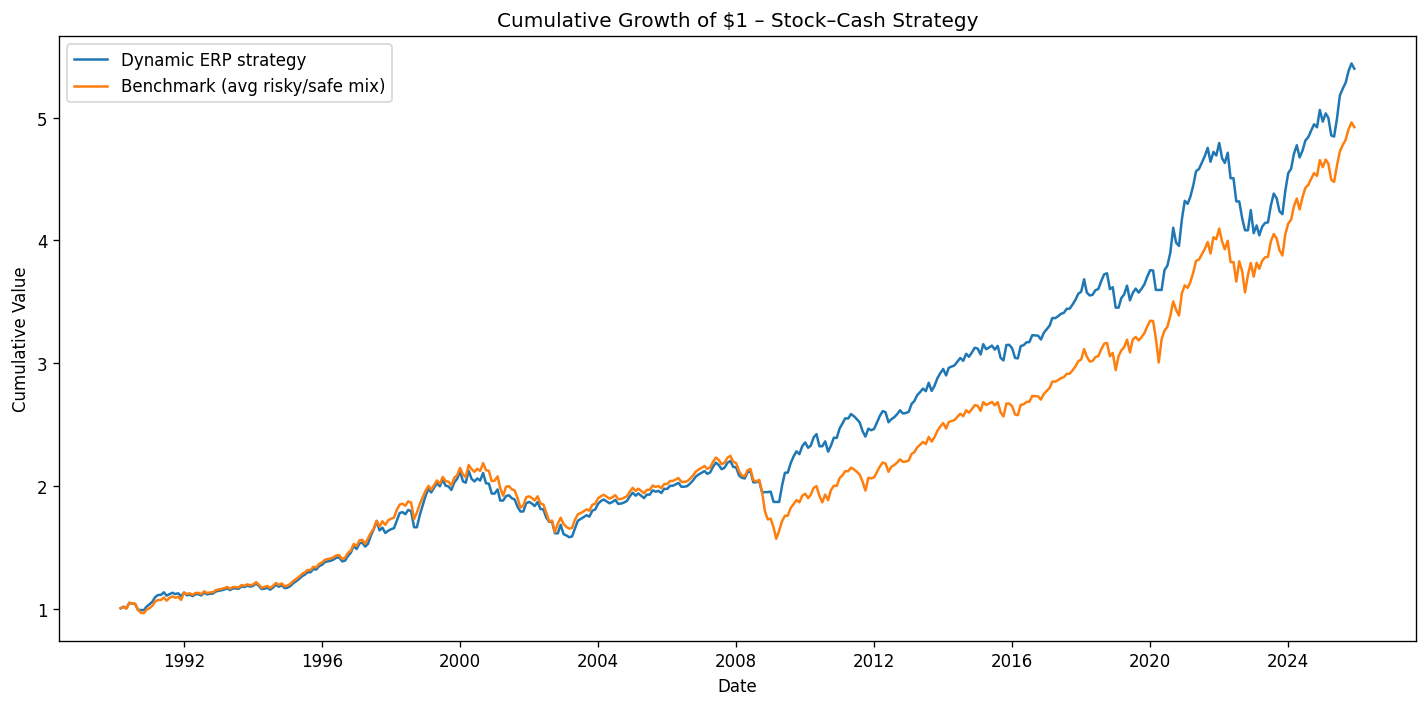

In [44]:
# ---- Cumulative performance ----
if isinstance(strategy.index, pd.PeriodIndex):
    idx_plot = strategy.index.to_timestamp("M")
else:
    idx_plot = strategy.index

cum_dyn = (1 + strategy["ret_dyn"]).cumprod()
cum_bench = (1 + strategy["ret_bench"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(idx_plot, cum_dyn, label="Dynamic ERP strategy")
plt.plot(idx_plot, cum_bench, label="Benchmark (avg risky/safe mix)")

plt.title("Cumulative Growth of $1 – Stock–Cash Strategy")
plt.ylabel("Cumulative Value")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

Strategy 2 using stocks and bonds

In [45]:
# ============================
# STOCK–BOND STRATEGY (S&P vs 3M T-bill)
# ============================

# Reuse the same w_stock (already lagged and aligned with data.index)
# Build new strategy DataFrame
strategy_sb = data[["sp500_ret", "rf_ret"]].copy()

# Align weights with strategy_sb index
w_stock_sb = w_stock.reindex(strategy_sb.index).fillna(0.5)

strategy_sb["w_stock"] = w_stock_sb
strategy_sb["w_bond"] = 1 - strategy_sb["w_stock"]

# Bond return = 3M T-bill monthly return
strategy_sb["ret_bond"] = strategy_sb["rf_ret"]

# Dynamic stock–bond strategy
strategy_sb["ret_dyn_sb"] = (
    strategy_sb["w_stock"] * strategy_sb["sp500_ret"] +
    strategy_sb["w_bond"] * strategy_sb["ret_bond"]
)

# Benchmark: constant mix with same average risky weight
w_bar_sb = strategy_sb["w_stock"].mean()
strategy_sb["ret_bench_sb"] = (
    w_bar_sb * strategy_sb["sp500_ret"] +
    (1 - w_bar_sb) * strategy_sb["ret_bond"]
)

In [46]:
# ============================
# Performance metrics – stock–bond
# ============================

# Geometric annualized returns
g_dyn_sb_m = geo_ret(strategy_sb["ret_dyn_sb"])
g_bench_sb_m = geo_ret(strategy_sb["ret_bench_sb"])

g_dyn_sb_a = (1 + g_dyn_sb_m) ** 12 - 1
g_bench_sb_a = (1 + g_bench_sb_m) ** 12 - 1

print("\n===== Geometric Annualized Returns – STOCK–BOND =====")
print("Dynamic stock–bond strategy            : {:.4%}".format(g_dyn_sb_a))
print("Benchmark stock–bond (avg weights)     : {:.4%}".format(g_bench_sb_a))


# Sharpe ratios (annualized)
ex_dyn_sb = strategy_sb["ret_dyn_sb"] - strategy_sb["rf_ret"]
ex_bench_sb = strategy_sb["ret_bench_sb"] - strategy_sb["rf_ret"]

sharpe_dyn_sb = sharpe_annual(ex_dyn_sb)
sharpe_bench_sb = sharpe_annual(ex_bench_sb)

print("\n===== Annualized Sharpe Ratios – STOCK–BOND (vs 3M T-Bill) =====")
print("Dynamic stock–bond strategy            : {:.3f}".format(sharpe_dyn_sb))
print("Benchmark stock–bond (avg weights)     : {:.3f}".format(sharpe_bench_sb))


===== Geometric Annualized Returns – STOCK–BOND =====
Dynamic stock–bond strategy            : 6.2499%
Benchmark stock–bond (avg weights)     : 5.9856%

===== Annualized Sharpe Ratios – STOCK–BOND (vs 3M T-Bill) =====
Dynamic stock–bond strategy            : 0.517
Benchmark stock–bond (avg weights)     : 0.465


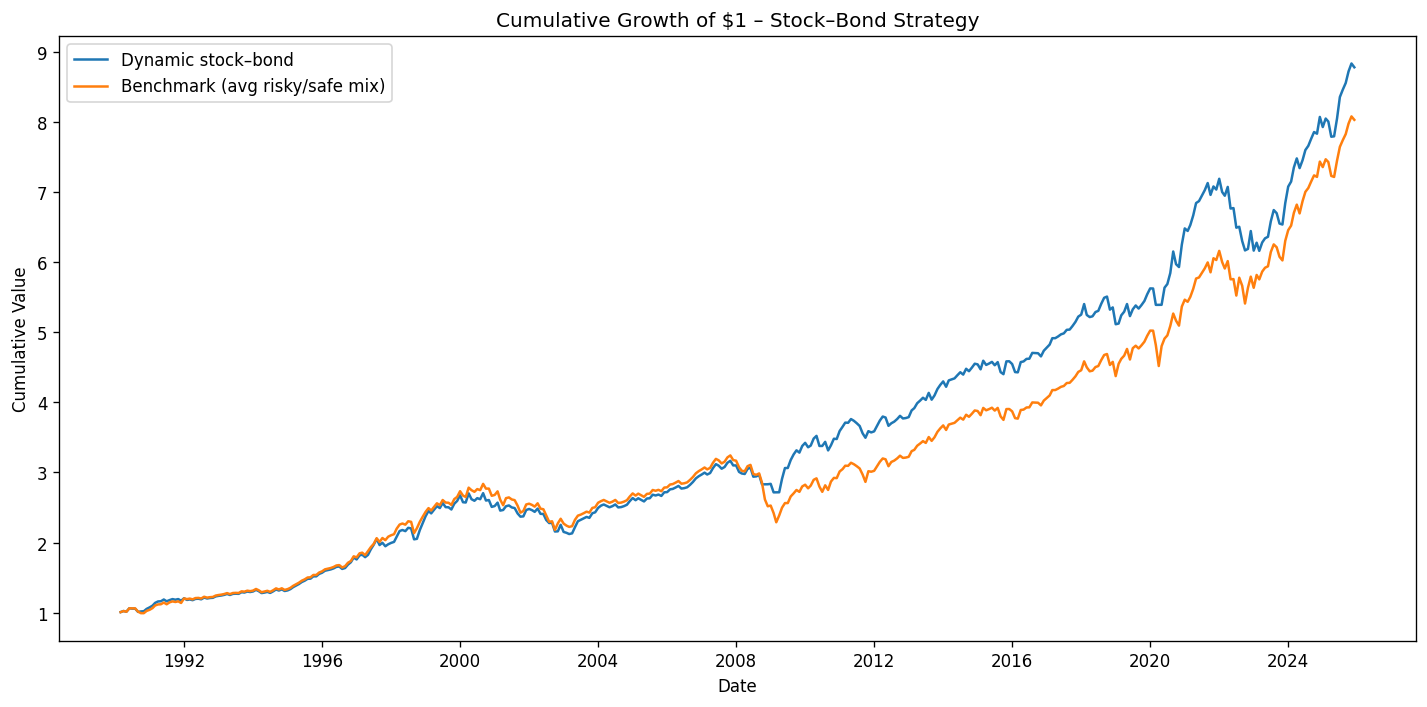

In [47]:
# ============================
# Cumulative performance plot
# ============================

# Convert PeriodIndex to Timestamp if needed
if isinstance(strategy_sb.index, pd.PeriodIndex):
    idx_plot_sb = strategy_sb.index.to_timestamp("M")
else:
    idx_plot_sb = strategy_sb.index

cum_dyn_sb = (1 + strategy_sb["ret_dyn_sb"]).cumprod()
cum_bench_sb = (1 + strategy_sb["ret_bench_sb"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(idx_plot_sb, cum_dyn_sb, label="Dynamic stock–bond")
plt.plot(idx_plot_sb, cum_bench_sb, label="Benchmark (avg risky/safe mix)")

plt.title("Cumulative Growth of $1 – Stock–Bond Strategy")
plt.ylabel("Cumulative Value")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()